<a href="https://colab.research.google.com/github/Lawson-Dong/SINDy_code_reproduction/blob/main/SINDy_fitting_Lorenz_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install "importlib-metadata<8.0.0,>=7.1.0"

!pip install pysindy

  Attempting uninstall: importlib-metadata
    Found existing installation: importlib_metadata 8.7.1
    Uninstalling importlib_metadata-8.7.1:
      Successfully uninstalled importlib_metadata-8.7.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.4/123.4 kB 4.1 MB/s eta 0:00:00


Data shape: (10000, 3)
Time steps: 10000, dt = 0.002

Identified system (Brunton 2016 Table 1 comparison):
(x0)' = -9.993 x0 +  9.993 x1
(x1)' =  27.968 x0 + -0.985 x1 + -0.999 x0 x2
(x2)' =  0.036 1 + -2.667 x2 +  0.999 x0 x1

True Lorenz equations:
  dx/dt = 10 y - 10 x
  dy/dt = 28 x - x z - y
  dz/dt = x y - 2.667 z


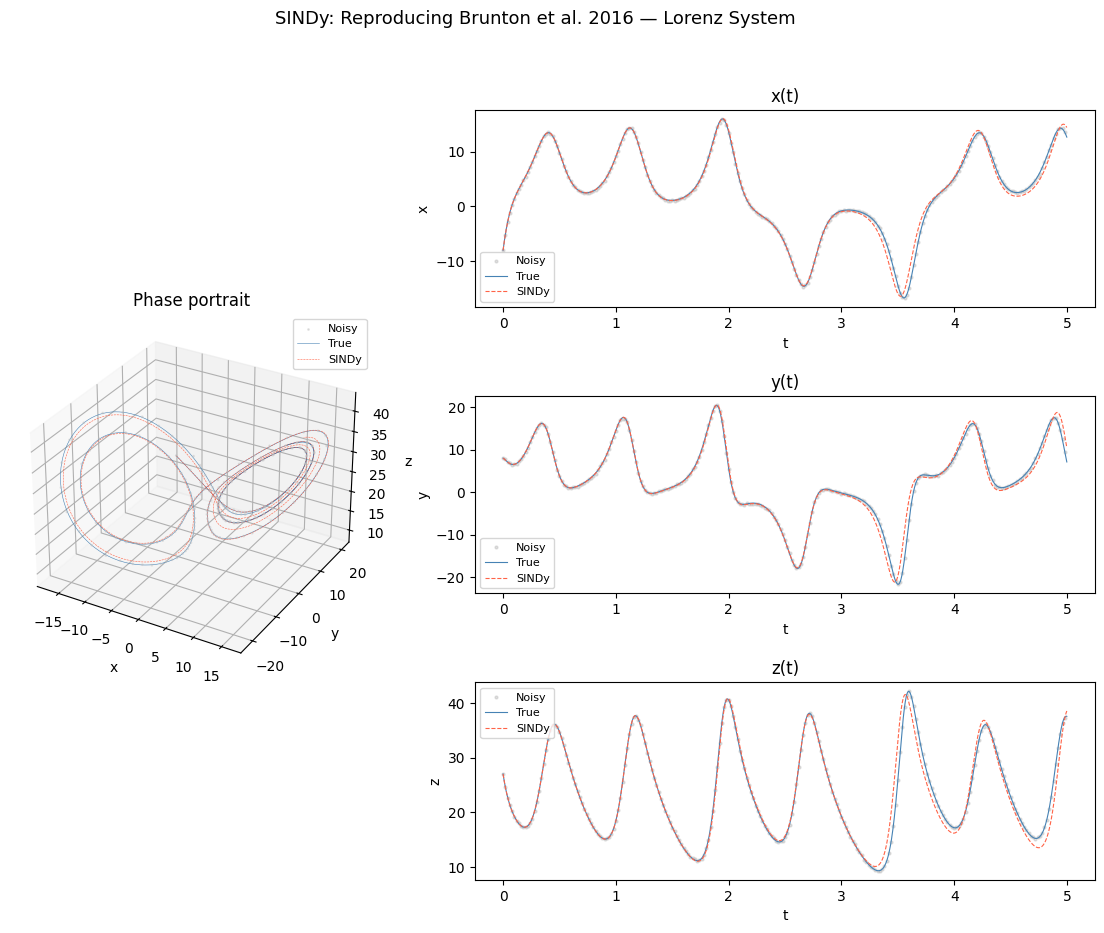


Figure saved → sindy_brunton2016.png

Coefficient comparison (identified vs true):
Feature       dx/dt(id)  dx/dt(true)  dy/dt(id)  dy/dt(true)  dz/dt(id)  dz/dt(true)
--------------------------------------------------------------------------------
1                +0.0000       +0.0000     +0.0000       +0.0000     +0.0358       +0.0000
x0               -9.9933      -10.0000    +27.9675      +28.0000     +0.0000       +0.0000
x1               +9.9929      +10.0000     -0.9845       -1.0000     +0.0000       +0.0000
x2               +0.0000       +0.0000     +0.0000       +0.0000     -2.6668       -2.6667
x0 x1            +0.0000       +0.0000     +0.0000       +0.0000     +0.9989       +1.0000
x0 x2            +0.0000       +0.0000     -0.9993       -1.0000     +0.0000       +0.0000


In [3]:
import numpy as np
import pysindy as ps
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ── Lorenz system (Brunton 2016, Fig. 3) ─────────────────────────────────────
# True parameters: σ=10, ρ=28, β=8/3
SIGMA, RHO, BETA = 10.0, 28.0, 8.0 / 3.0


def lorenz(t, state):
    x, y, z = state
    return [
        SIGMA * (y - x),
        x * (RHO - z) - y,
        x * y - BETA * z,
    ]


# ── 1. Generate data ──────────────────────────────────────────────────────────
np.random.seed(42)

dt = 0.002
t_span = (0.0, 20.0)
t_eval = np.arange(*t_span, dt)
x0 = [-8.0, 8.0, 27.0]  # initial condition used in Brunton 2016

sol = solve_ivp(lorenz, t_span, x0, t_eval=t_eval, method="RK45", rtol=1e-10)
X_clean = sol.y.T  # shape (N, 3)

# Add measurement noise (σ_n = 0.01 × std, matching paper's 1% noise level)
noise_std = 0.01 * X_clean.std(axis=0)
X_noisy = X_clean + np.random.randn(*X_clean.shape) * noise_std

print("Data shape:", X_noisy.shape)
print(f"Time steps: {len(t_eval)}, dt = {dt}")

# ── 2. Fit SINDy with polynomial library (degree 2) ──────────────────────────
# Brunton 2016 uses STLSQ (Sequential Thresholded Least Squares) with λ=0.025
optimizer = ps.STLSQ(threshold=0.025, alpha=0.05)
library = ps.PolynomialLibrary(degree=2, include_bias=True)

model = ps.SINDy(
    optimizer=optimizer,
    feature_library=library,
    differentiation_method=ps.FiniteDifference(),
)
model.fit(X_noisy, t=dt)

# ── 3. Print identified equations ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("Identified system (Brunton 2016 Table 1 comparison):")
print("=" * 60)
model.print(precision=3)

print("\nTrue Lorenz equations:")
print("  dx/dt = 10 y - 10 x")
print("  dy/dt = 28 x - x z - y")
print("  dz/dt = x y - 2.667 z")

# ── 4. Simulate identified model and compare ─────────────────────────────────
t_sim = t_eval[: int(5.0 / dt)]  # simulate first 5 s for legibility
X_sim = model.simulate(x0, t=t_sim)

# ── 5. Visualise ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
fig.suptitle("SINDy: Reproducing Brunton et al. 2016 — Lorenz System", fontsize=13)

# GridSpec: left column (wider) for 3D plot, right two columns for time series
gs = fig.add_gridspec(3, 3, width_ratios=[1.4, 1, 1], hspace=0.45, wspace=0.35)

n_sim = len(t_sim)
# Subsample noisy data for scatter (every 10th point avoids overplotting)
step = 10
idx = slice(0, n_sim, step)

ax3d = fig.add_subplot(gs[:, 0], projection="3d")
ax3d.scatter(*X_noisy[:n_sim:step].T, s=1, color="silver", alpha=0.4, label="Noisy")
ax3d.plot(*X_clean[:n_sim].T, lw=0.4, color="steelblue", label="True")
ax3d.plot(*X_sim.T, lw=0.4, color="tomato", linestyle="--", label="SINDy")
ax3d.set_xlabel("x")
ax3d.set_ylabel("y")
ax3d.set_zlabel("z")
ax3d.set_title("Phase portrait")
ax3d.legend(fontsize=8)

labels = ["x", "y", "z"]
for i, lbl in enumerate(labels):
    ax = fig.add_subplot(gs[i, 1:])
    ax.scatter(t_sim[idx], X_noisy[:n_sim:step, i], s=4, color="silver",
               alpha=0.5, label="Noisy", zorder=1)
    ax.plot(t_sim, X_clean[:n_sim, i], lw=0.8, color="steelblue",
            label="True", zorder=2)
    ax.plot(t_sim, X_sim[:, i], lw=0.8, color="tomato", linestyle="--",
            label="SINDy", zorder=3)
    ax.set_xlabel("t")
    ax.set_ylabel(lbl)
    ax.set_title(f"{lbl}(t)")
    ax.legend(fontsize=8)
plt.savefig("sindy_brunton2016.png", dpi=150)
plt.show()
print("\nFigure saved → sindy_brunton2016.png")

# ── 6. Coefficient comparison table ──────────────────────────────────────────
print("\n" + "=" * 60)
print("Coefficient comparison (identified vs true):")
print("=" * 60)

feat_names = model.get_feature_names()
coef_matrix = model.coefficients()  # shape (n_states, n_features)

# True Lorenz coefficients (STLSQ basis ordering: 1, x, y, z, x², xy, xz, y², yz, z²)
true_coefs = np.zeros_like(coef_matrix)
#  dx/dt = -σx + σy  → indices for x=1, y=2
true_coefs[0, 1] = -SIGMA  # x
true_coefs[0, 2] = SIGMA   # y
#  dy/dt = ρx - y - xz → indices for x=1, y=2, xz=6
true_coefs[1, 1] = RHO     # x
true_coefs[1, 2] = -1.0    # y
true_coefs[1, 6] = -1.0    # xz  (index depends on library ordering)
#  dz/dt = -βz + xy  → indices for z=3, xy=5
true_coefs[2, 3] = -BETA   # z
true_coefs[2, 5] = 1.0     # xy

print(f"{'Feature':<12}", end="")
for state in labels:
    print(f"  d{state}/dt(id)  d{state}/dt(true)", end="")
print()
print("-" * 80)
for j, fname in enumerate(feat_names):
    row = f"{fname:<12}"
    any_nonzero = False
    for i in range(len(labels)):
        c_id = coef_matrix[i, j]
        c_tr = true_coefs[i, j]
        row += f"  {c_id:+10.4f}    {c_tr:+10.4f}"
        if abs(c_id) > 1e-4 or abs(c_tr) > 1e-4:
            any_nonzero = True
    if any_nonzero:
        print(row)
